# Practical 2A: Multiclass Classification using DNN on OCR Letter Recognition

## Aim
Build a Deep Neural Network to classify English capital letters A to Z using the OCR letter recognition dataset.

## Dataset
Local file used in this notebook: dl/2/letter-recognition.data

## What you will learn
- How to load a dataset without header names
- How to encode class labels
- How to scale numeric features
- How to build a softmax DNN for multiclass classification
- How to evaluate accuracy, classification report, and confusion matrix

Note: This notebook uses TensorFlow/Keras. No PyTorch code is used.

In [ ]:
# If imports fail on your machine, install these packages once:
# !pip install pandas numpy scikit-learn matplotlib tensorflow

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

## Step 1: Load the dataset

The first column is the letter label. The remaining 16 columns are numeric features extracted from the letter image.

In [2]:
DATA_PATH = Path("dl/2/letter-recognition.data")

feature_names = [
    "x_box", "y_box", "width", "height", "onpix", "x_bar", "y_bar", "x2bar",
    "y2bar", "xybar", "x2ybar", "xy2bar", "x_edge", "x_edge_y", "y_edge", "y_edge_x"
]

data = pd.read_csv(DATA_PATH, header=None, names=["letter"] + feature_names)

print("Dataset shape:", data.shape)
data.head()

Dataset shape: (20000, 17)


,letter,x_box,y_box,width,height,onpix,x_bar,y_bar,x2bar,y2bar,xybar,x2ybar,xy2bar,x_edge,x_edge_y,y_edge,y_edge_x
0,T,2,8,3,5,1,8,13,0,6,6,10,8,0,8,0,8
1,I,5,12,3,7,2,10,5,5,4,13,3,9,2,8,4,10
2,D,4,11,6,8,6,10,6,2,6,10,3,7,3,7,3,9
3,N,7,11,6,6,3,5,9,4,6,4,4,10,6,10,2,8
4,G,2,1,3,1,1,8,6,6,6,6,5,9,1,7,5,10


In [3]:
print(data.info())
print("\nClass count:")
print(data["letter"].value_counts().sort_index())

<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 17 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   letter    20000 non-null  str  
 1   x_box     20000 non-null  int64
 2   y_box     20000 non-null  int64
 3   width     20000 non-null  int64
 4   height    20000 non-null  int64
 5   onpix     20000 non-null  int64
 6   x_bar     20000 non-null  int64
 7   y_bar     20000 non-null  int64
 8   x2bar     20000 non-null  int64
 9   y2bar     20000 non-null  int64
 10  xybar     20000 non-null  int64
 11  x2ybar    20000 non-null  int64
 12  xy2bar    20000 non-null  int64
 13  x_edge    20000 non-null  int64
 14  x_edge_y  20000 non-null  int64
 15  y_edge    20000 non-null  int64
 16  y_edge_x  20000 non-null  int64
dtypes: int64(16), str(1)
memory usage: 2.6 MB
None

Class count:
letter
A    789
B    766
C    736
D    805
E    768
F    775
G    773
H    734
I    755
J    747
K    739
L    761
M    792
N    783


## Step 2: Prepare input and output

Neural networks need numeric labels. LabelEncoder converts A to 0, B to 1, and so on.

In [4]:
X = data.drop("letter", axis=1)
y_letters = data["letter"]

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_letters)

print("Classes:", label_encoder.classes_)
print("Example encoded labels:", y[:10])

Classes: ['A' 'B' 'C' 'D' 'E' 'F' 'G' 'H' 'I' 'J' 'K' 'L' 'M' 'N' 'O' 'P' 'Q' 'R'
 'S' 'T' 'U' 'V' 'W' 'X' 'Y' 'Z']
Example encoded labels: [19  8  3 13  6 18  1  0  9 12]


## Step 3: Split and scale

We use stratify=y so that train and test sets keep a similar distribution of letters.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train shape:", X_train_scaled.shape)
print("Test shape:", X_test_scaled.shape)

Train shape: (16000, 16)
Test shape: (4000, 16)


## Step 4: Build the DNN multiclass model

The last layer has 26 neurons because there are 26 letters. Softmax converts scores into class probabilities.

In [6]:
model = keras.Sequential([
    layers.Input(shape=(X_train_scaled.shape[1],)),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(64, activation="relu"),
    layers.Dense(26, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         2,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 26)             │         1,690 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,122 (47.35 KB)

 Trainable params: 12,122 (47.35 KB)

 Non-trainable params: 0 (0.00 B)

## Step 5: Train the model

A small DNN is enough for this tabular OCR feature dataset.

In [7]:
history = model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=64,
    verbose=1
)

Epoch 1/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4375 - loss: 2.0745 - val_accuracy: 0.6716 - val_loss: 1.1756
Epoch 2/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6876 - loss: 1.0499 - val_accuracy: 0.7719 - val_loss: 0.8276
Epoch 3/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7549 - loss: 0.8340 - val_accuracy: 0.8053 - val_loss: 0.6887
Epoch 4/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7784 - loss: 0.7161 - val_accuracy: 0.8303 - val_loss: 0.6010
Epoch 5/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8007 - loss: 0.6409 - val_accuracy: 0.8481 - val_loss: 0.5352
Epoch 6/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8217 - loss: 0.5773 - val_accuracy: 0.8591 - val_loss: 0.4842
Epoch 7/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8351 - loss: 0.5312 - val_accuracy: 0.8719 - val_loss: 0.4490
Epoch 8/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8484 - loss: 0.4948 - val_accuracy: 0.

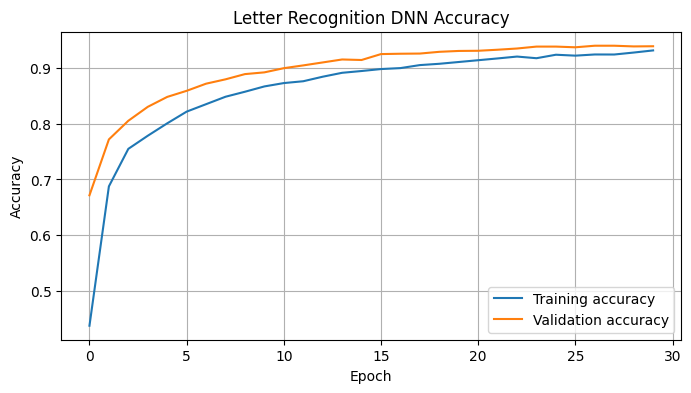

In [8]:
plt.figure(figsize=(8, 4))
plt.plot(history.history["accuracy"], label="Training accuracy")
plt.plot(history.history["val_accuracy"], label="Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Letter Recognition DNN Accuracy")
plt.legend()
plt.grid(True)
plt.show()

## Step 6: Evaluate the model

In [9]:
test_loss, test_accuracy = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"Test accuracy: {test_accuracy:.4f}")

y_prob = model.predict(X_test_scaled, verbose=0)
y_pred = np.argmax(y_prob, axis=1)

print(classification_report(
    y_test,
    y_pred,
    target_names=label_encoder.classes_
))

Test accuracy: 0.9402
              precision    recall  f1-score   support

           A       0.98      0.96      0.97       158
           B       0.87      0.92      0.90       153
           C       0.95      0.95      0.95       147
           D       0.93      0.97      0.95       161
           E       0.89      0.96      0.92       154
           F       0.92      0.92      0.92       155
           G       0.93      0.90      0.92       155
           H       0.89      0.85      0.87       147
           I       0.98      0.89      0.93       151
           J       0.94      0.98      0.96       149
           K       0.88      0.93      0.90       148
           L       0.99      0.94      0.96       152
           M       0.99      0.97      0.98       158
           N       0.94      0.90      0.92       157
           O       0.97      0.93      0.95       150
           P       0.96      0.93      0.95       161
           Q       0.94      0.98      0.96       157
     

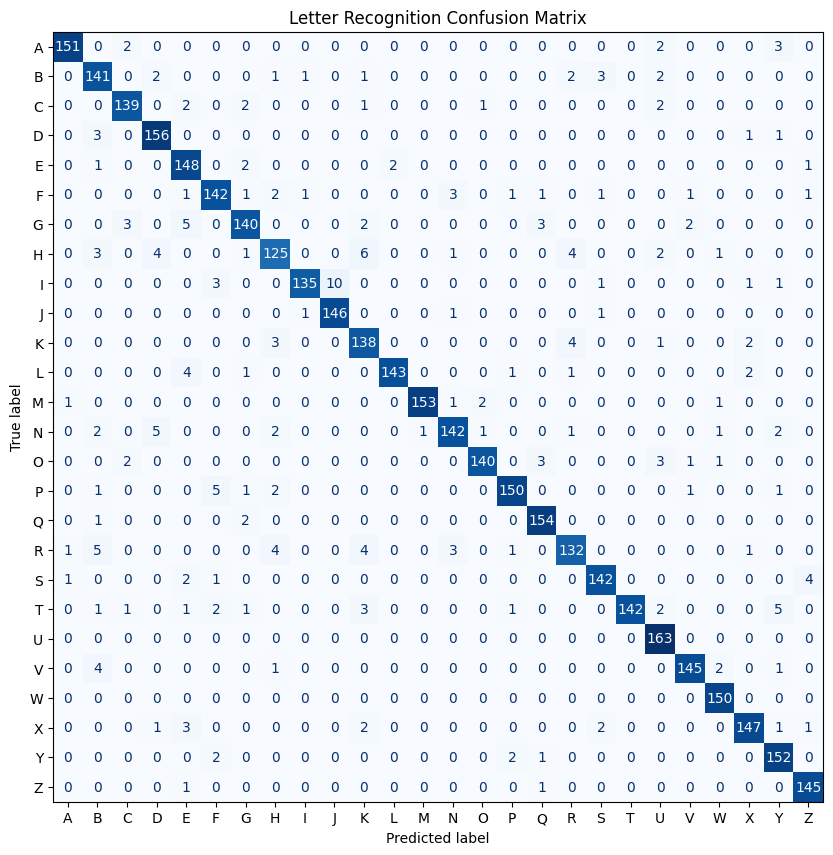

In [10]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(10, 10))
display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)
display.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Letter Recognition Confusion Matrix")
plt.show()

## Step 7: Try a few predictions

In [11]:
sample_rows = X_test.iloc[:10]
sample_scaled = scaler.transform(sample_rows)
sample_predictions = model.predict(sample_scaled, verbose=0)
predicted_numbers = np.argmax(sample_predictions, axis=1)
predicted_letters = label_encoder.inverse_transform(predicted_numbers)
actual_letters = label_encoder.inverse_transform(y_test[:10])

pd.DataFrame({
    "Actual": actual_letters,
    "Predicted": predicted_letters
})

,Actual,Predicted
0,R,R
1,M,M
2,B,B
3,P,P
4,J,J
5,L,L
6,P,P
7,G,G
8,Z,Z
9,V,V


## Conclusion

We created a multiclass DNN classifier for recognizing capital letters. The key idea is that multiclass classification uses a softmax output layer and sparse categorical crossentropy loss.